In [43]:
import pandas as pd

In [44]:
df = pd.read_csv('snap_data.csv')
df

,GEO_ID,NAME,S2201_C01_001E,S2201_C01_001M,S2201_C01_002E,S2201_C01_002M,S2201_C01_003E,S2201_C01_003M,S2201_C01_004E,S2201_C01_004M,...,S2201_C06_034E,S2201_C06_034M,S2201_C06_035E,S2201_C06_035M,S2201_C06_036E,S2201_C06_036M,S2201_C06_037E,S2201_C06_037M,S2201_C06_038E,S2201_C06_038M
0,Geography,Geographic Area Name,Estimate!!Total!!Households,Margin of Error!!Total!!Households,Estimate!!Total!!Households!!With one or more ...,Margin of Error!!Total!!Households!!With one o...,Estimate!!Total!!Households!!No people in the ...,Margin of Error!!Total!!Households!!No people ...,Estimate!!Total!!Households!!Married-couple fa...,Margin of Error!!Total!!Households!!Married-co...,...,Estimate!!Percent households not receiving foo...,Margin of Error!!Percent households not receiv...,Estimate!!Percent households not receiving foo...,Margin of Error!!Percent households not receiv...,Estimate!!Percent households not receiving foo...,Margin of Error!!Percent households not receiv...,Estimate!!Percent households not receiving foo...,Margin of Error!!Percent households not receiv...,Estimate!!Percent households not receiving foo...,Margin of Error!!Percent households not receiv...
1,1400000US48113000100,Census Tract 1; Dallas County; Texas,1729,161,526,105,1203,164,962,140,...,(X),(X),(X),(X),7.9,5.7,26,10.9,66.1,12.5
2,1400000US48113000201,Census Tract 2.01; Dallas County; Texas,1213,142,352,89,861,120,719,88,...,(X),(X),(X),(X),8,5.7,23.1,9.7,69,10.7
3,1400000US48113000202,Census Tract 2.02; Dallas County; Texas,1680,229,381,142,1299,206,825,186,...,(X),(X),(X),(X),14,12.6,24.1,8.8,61.9,12.5
4,1400000US48113000300,Census Tract 3; Dallas County; Texas,2139,311,542,120,1597,308,1054,301,...,(X),(X),(X),(X),8.2,6.2,21.3,14.7,70.5,14.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
641,1400000US48113021100,Census Tract 211; Dallas County; Texas,1763,567,1084,578,679,201,411,214,...,(X),(X),(X),(X),5.3,7.7,51.6,20.4,43.2,21.8
642,1400000US48113021200,Census Tract 212; Dallas County; Texas,1515,176,563,152,952,190,828,260,...,(X),(X),(X),(X),8.4,5.7,29.4,11.8,62.2,13.1
643,1400000US48113980000,Census Tract 9800; Dallas County; Texas,0,15,0,15,0,15,0,15,...,(X),(X),(X),(X),-,**,-,**,-,**
644,1400000US48113980100,Census Tract 9801; Dallas County; Texas,0,15,0,15,0,15,0,15,...,(X),(X),(X),(X),-,**,-,**,-,**


# SNAP Data Mapping

In [45]:
import shapely
import numpy as np
import fiona

In [46]:
import geopandas as gpd
import matplotlib.pyplot as plt

In [47]:
gdf = gpd.read_file("tl_2024_48_tract.zip")

In [48]:
import zipfile

with zipfile.ZipFile("tl_2024_48_tract.zip", "r") as zip_ref:
    zip_ref.extractall("tl_2024_48_tract")

In [49]:
dallas = gdf[gdf["COUNTYFP"] == "113"]

In [50]:
#merging
merged = dallas.merge(
    df,
    left_on="GEOIDFQ",
    right_on="GEO_ID",
    how="left"
)

In [51]:
#for now, I am seeing looking at percentage of households with SNAP
df_subset = df[[
    "GEO_ID",
    "S2201_C04_001E"
]]

In [52]:
df_subset

,GEO_ID,S2201_C04_001E
0,Geography,Estimate!!Percent households receiving food st...
1,1400000US48113000100,0
2,1400000US48113000201,4.1
3,1400000US48113000202,3.2
4,1400000US48113000300,0
...,...,...
641,1400000US48113021100,18
642,1400000US48113021200,7.7
643,1400000US48113980000,-
644,1400000US48113980100,-


In [53]:
merged["S2201_C04_001E"] = pd.to_numeric(
    merged["S2201_C04_001E"],
    errors="coerce"
)

In [54]:
merged
merged["S2201_C04_001E"]

0       5.2
1       3.7
2      20.2
3       5.4
4       0.8
       ... 
640     8.1
641    15.7
642    24.9
643    14.7
644    11.6
Name: S2201_C04_001E, Length: 645, dtype: float64

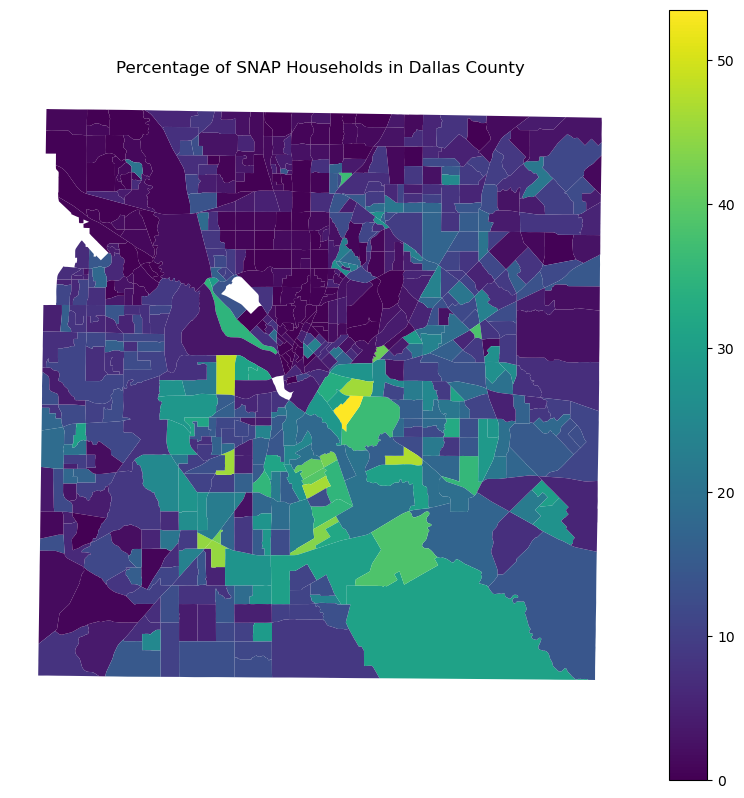

In [56]:
fig, ax = plt.subplots(figsize=(10, 10))

merged.plot(
    column="S2201_C04_001E",
    cmap="viridis",
    legend=True,
    ax=ax
)

plt.title("Percentage of SNAP Households in Dallas County")
plt.axis("off")
plt.show()